## **Phase 1: Dataset Overview and EDA**

## DATA OVERVIEW

### Step 0: Imports and Reading Data

In [66]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

df = pd.read_parquet('/Users/itsnada/homeworks/ملخصات/مشروع تخرج/ML/NEW MODELS/RF Model 2/sample_stratified.parquet')


### Step 1: Data Understanding

In [67]:
df.shape

(250001, 73)

The dataset contains **250,001** rows and **73** features, which indicates a large and information-rich IoT flow dataset.
This size is adequate for training machine learning models, especially tree-based ones such as Random Forest.

In [68]:
df.head()

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label
0,4070,46642,6,38264857,1,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.466408e+06,2.185382e+06,6888783.0,628731.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,32779781.0,5.463297e+06,2.393949e+06,6888783.0,628731.0,0,0,24,140,0.026134,0.182935,0.0,0.0,0.0,0.0,0,7,1,0,1,0,7.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.000000,0.0,0.0,6.272688e+06,5.199459e+05,6888783.0,5485076.0,DoS SYN Flood
1,48964,6668,6,42928780,9,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.366098e+06,1.351293e+06,7701271.0,4431864.0,42928780.0,5.366098e+06,1.351293e+06,7701271.0,4431864.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,180,0,0.209650,0.000000,0.0,0.0,0.0,0.0,0,9,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,0,0,20,22853246.0,0.000000,22853246.0,22853246.0,6.691845e+06,1.452990e+06,7701271.0,5026540.0,DoS SYN Flood
2,31153,8009,6,81403548,14,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.814539e+06,2.407981e+06,9626744.0,39867.0,81403548.0,6.261811e+06,1.808999e+06,9626744.0,3807847.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,280,24,0.171983,0.012284,0.0,0.0,0.0,0.0,0,14,1,0,1,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,65535,0,20,4906412.0,0.000000,4906412.0,4906412.0,6.608117e+06,1.734689e+06,9626744.0,5016194.0,DoS SYN Flood
3,17964,443,6,117365026,22,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.588811e+06,1.213805e+06,8222010.0,2790963.0,117365026.0,5.588811e+06,1.213805e+06,8222010.0,2790963.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,440,0,0.187449,0.000000,0.0,0.0,0.0,0.0,0,22,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,0,0,20,3961413.0,994607.264396,4904042.0,2790963.0,5.971728e+06,9.155742e+05,8222010.0,5001390.0,DoS SYN Flood
4,46376,6668,6,34571236,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.761873e+06,2.152767e+06,10083655.0,4488648.0,34571236.0,5.761873e+06,2.152767e+06,10083655.0,4488648.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,140,0,0.202480,0.000000,0.0,0.0,0.0,0.0,0,7,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,512,0,0,20,4607843.0,168567.185567,4727038.0,4488648.0,7.854140e+06,3.153010e+06,10083655.0,5624626.0,DoS SYN Flood


#### Observation:
The initial records show highly variable flow durations and packet statistics, indicating the presence of both normal and attack traffic with diverse behaviors.

In [69]:
df.columns

Index(['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet',
       'Total Bwd packets', 'Total Length of Fwd Packet',
       'Total Length of Bwd Packet', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std',
       'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
       'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
       'Dow


#### Observation:

The dataset contains a wide set of flow-level attributes, including port metadata, packet statistics, timing features, and the final label column.

In [70]:
df.dtypes

Src Port              int64
Dst Port              int64
Protocol              int64
Flow Duration         int64
Total Fwd Packet      int64
                     ...   
Idle Mean           float64
Idle Std            float64
Idle Max            float64
Idle Min            float64
label                object
Length: 73, dtype: object

#### Observation:

Most features are numerical while only the label is categorical. This simplifies preprocessing and is ideal for tree-based models such as Random Forest.

In [71]:
df.describe()

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,250001.000000,250001.000000,250001.000000,2.500010e+05,250001.000000,250001.000000,2.500010e+05,2.500010e+05,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,250001.000000,250001.0,250001.000000,250001.000000,2.500010e+05,250001.000000,250001.000000,250001.000000,250001.000000,2.500010e+05,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.0,250001.000000,250001.000000,250001.000000,250001.000000,250001.0,250001.0,250001.0,2.500010e+05,250001.000000,2.500010e+05,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,250001.000000,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05,2.500010e+05
mean,31942.072764,13095.261039,8.455914,6.161896e+07,48.765053,6.141143,7.459125e+02,1.094286e+02,140.817545,114.797369,122.637773,9.617809,48.206895,33.536314,37.072673,5.597260,8.860518e+06,2.489745e+06,1.342730e+07,6.487261e+06,5.861713e+07,9.269675e+06,2.013695e+06,1.317205e+07,7.425060e+06,4.282152e+06,1.022181e+06,4.260073e+05,1.545662e+06,5.640981e+05,0.006272,0.0,236.636509,28.489982,3.364547e+03,49.906536,94.752625,180.979656,40.142031,3.059718e+04,0.040208,7.084584,0.369411,0.228199,1.216263,0.0,0.655973,178.150335,122.637773,37.072673,0.0,0.0,0.0,2.827542e+02,8.363107,7.956053e+03,9.740809,224.956796,1.575342,15.617074,7817.711741,5016.921128,10.283483,19.082036,3.913255e+06,1.900339e+06,5.917579e+06,2.356605e+06,1.024423e+07,1.814070e+06,1.328597e+07,8.762060e+06
std,20251.200753,18043.023593,4.601849,4.797812e+07,3405.368826,1158.197726,1.785661e+04,4.872598e+03,429.523229,358.710712,365.267023,81.203319,272.813662,209.351029,214.856129,63.769239,1.646876e+07,4.755787e+06,1.837100e+07,1.659388e+07,4.961472e+07,1.756692e+07,4.350439e+06,1.921470e+07,1.762127e+07,1.636953e+07,5.025727e+06,2.202194e+06,6.635559e+06,4.530763e+06,0.078947,0.0,816.811730,376.629792,7.673614e+04,6127.145463,325.410336,489.653235,170.252498,1.503406e+05,0.238544,8.463951,0.512144,7.559993,23.106443,0.0,2.656642,514.668825,365.267023,214.856129,0.0,0.0,0.0,1.774249e+04,92.184323,6.075293e+05,1201.844741,1873.145688,436.927583,726.008590,18070.342226,14921.845006,92.060883,7.701106,7.919426e+06,5.001864e+06,1.220395e+07,5.420454e+06,1.708572e+07,4.304894e+06,1.846318e+07,1.697087e+07
min,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+0

#### Observation:
Several features such as Flow Duration and IAT values show extremely large ranges, suggesting heavy-tailed distributions and possible outliers, which is common in IoT attack datasets.

### Step 2: Data Preparation

In [72]:
df.columns

Index(['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet',
       'Total Bwd packets', 'Total Length of Fwd Packet',
       'Total Length of Bwd Packet', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std',
       'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
       'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
       'Dow

In [73]:
drop_cols = [
    "Flow ID", "Src IP", "Dst IP", "Timestamp", "src_path", "cnt", "NeedManualLabel",
    "Fwd URG Flags", "Bwd URG Flags", "CWR Flag Count", "ECE Flag Count",
    "Packet Length Mean",
    "Flow Bytes/s", "Flow Packets/s"
]

In [74]:
# Delete unimportant columns
df = df.drop(columns=drop_cols, errors="ignore")

print(" Columns after deletion:", df.shape[1])
print(" Saved columns:", df.columns.tolist()[:20], "...")

 Columns after deletion: 73
 Saved columns: ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min'] ...


#### Observation:
Removing IP addresses and metadata prevents the model from learning device-specific identifiers and ensures it focuses on behavioral patterns instead of artifacts.

In [75]:
df.isna().sum()

Src Port            0
Dst Port            0
Protocol            0
Flow Duration       0
Total Fwd Packet    0
                   ..
Idle Mean           0
Idle Std            0
Idle Max            0
Idle Min            0
label               0
Length: 73, dtype: int64

#### Observation:
No missing values were found across all features. This means the dataset is complete and ready for training without requiring any imputation.

In [76]:
df.loc[df.duplicated()]

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label


#### Observation:
No fully duplicated rows were detected in the dataset. The duplicate check returned an empty DataFrame, indicating that all records are unique at the row level. This confirms that the dataset does not contain repeated traffic flows, and no duplicate removal was required at this stage.

In [77]:
df.loc[df.duplicated(subset=['Src Port'])]

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label
15,49153,64466,6,20965106,1,4,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,5.241276e+06,3.128679e+06,7103645.0,580479.0,0.0,0.000000e+00,0.000000,0.0,0.0,13964867.0,4.654956e+06,3.552508e+06,7103645.0,580479.0,0,0,24,80,0.047698,0.190793,0.0,0.0,0.00,0.0000,0,4,1,0,1,0,4.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,6.794876e+06,4.482438e+05,7103645.0,6280743.0,DoS SYN Flood
25,4070,44113,6,15828485,1,3,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,5.276162e+06,4.169398e+06,7955768.0,472450.0,0.0,0.000000e+00,0.000000,0.0,0.0,7872717.0,3.936358e+06,4.898706e+06,7400267.0,472450.0,0,0,24,60,0.063177,0.189532,0.0,0.0,0.00,0.0000,0,3,1,0,1,0,3.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,7.678018e+06,3.927985e+05,7955768.0,7400267.0,DoS SYN Flood
33,4070,10150,6,12931460,1,3,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,4.310487e+06,3.428040e+06,6547153.0,363823.0,0.0,0.000000e+00,0.000000,0.0,0.0,6910976.0,3.455488e+06,4.372275e+06,6547153.0,363823.0,0,0,24,60,0.077331,0.231992,0.0,0.0,0.00,0.0000,0,3,1,0,1,0,3.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,6.283818e+06,3.724112e+05,6547153.0,6020484.0,DoS SYN Flood
46,49153,4579,6,58784624,1,8,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,7.348078e+06,4.473098e+06,17111306.0,811310.0,0.0,0.000000e+00,0.000000,0.0,0.0,41673318.0,5.953331e+06,2.277513e+06,7074433.0,811310.0,0,0,24,160,0.017011,0.136090,0.0,0.0,0.00,0.0000,0,8,1,0,1,0,8.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,8.281902e+06,3.899289e+06,17111306.0,6465205.0,DoS SYN Flood
55,4070,12350,6,65562982,1,10,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,6.556298e+06,2.821486e+06,11647665.0,472440.0,0.0,0.000000e+00,0.000000,0.0,0.0,60261188.0,6.695688e+06,2.955893e+06,11647665.0,472440.0,0,0,24,200,0.015253,0.152525,0.0,0.0,0.00,0.0000,0,10,1,0,1,0,10.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.0,0.0,0.0,0.0,7.232282e+06,1.953239e+06,11647665.0,5301794.0,DoS SYN Flood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249996,52286,80,6,0,2,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,40,0,0.000000,0.000000,0.0,0.0,0.00,0.0000,0,0,2,0,0,0,0.0,0.000000,0.000000,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,DoS HTTP Flood
249997,80,44094,6,5397086,2,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,5.397086e+06,0.000000e+00,5397086.0,5

#### Observation:
Although many flows share the same source port, their other numerical characteristics differ significantly. This indicates that they are independent connections, not true duplicates.

In [78]:
# cheking an example duplicate
df.query('`Src Port` == 49153')

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label
5,49153,50523,6,31022425,1,5,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,6.204485e+06,3.673695e+06,11068590.0,855309.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,25666671.0,6.416668e+06,4.206491e+06,11068590.0,855309.0,0,0,24,100,0.032235,0.161174,0.0,0.0,0.000000,0.000000,0,5,1,0,1,0,5.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.000000e+00,0.000000,0.0,0.0,7.541779e+06,2.464213e+06,11068590.0,5355754.0,DoS SYN Flood
15,49153,64466,6,20965106,1,4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,5.241276e+06,3.128679e+06,7103645.0,580479.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,13964867.0,4.654956e+06,3.552508e+06,7103645.0,580479.0,0,0,24,80,0.047698,0.190793,0.0,0.0,0.000000,0.000000,0,4,1,0,1,0,4.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.000000e+00,0.000000,0.0,0.0,6.794876e+06,4.482438e+05,7103645.0,6280743.0,DoS SYN Flood
46,49153,4579,6,58784624,1,8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,7.348078e+06,4.473098e+06,17111306.0,811310.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,41673318.0,5.953331e+06,2.277513e+06,7074433.0,811310.0,0,0,24,160,0.017011,0.136090,0.0,0.0,0.000000,0.000000,0,8,1,0,1,0,8.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.000000e+00,0.000000,0.0,0.0,8.281902e+06,3.899289e+06,17111306.0,6465205.0,DoS SYN Flood
63,49153,649,6,67196255,1,11,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,6.108750e+06,2.100558e+06,8952456.0,645582.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,61478403.0,6.147840e+06,2.209962e+06,8952456.0,645582.0,0,0,24,220,0.014882,0.163700,0.0,0.0,0.000000,0.000000,0,11,1,0,1,0,11.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,4.546309e+06,0.000000,4546309.0,4546309.0,6.889374e+06,8.910434e+05,8952456.0,5717852.0,DoS SYN Flood
97,49153,25926,6,17676951,1,3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,5.892317e+06,4.444795e+06,9601585.0,965680.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,8075366.0,4.037683e+06,4.344468e+06,7109686.0,965680.0,0,0,24,60,0.056571,0.169713,0.0,0.0,0.000000,0.000000,0,3,1,0,1,0,3.0,0.000000,0.0,0.0,0,0,0,0,0,0,0,0,1,0,29200,0,0,24,0.000000e+00,0.000000,0.0,0.0,8.355636e+06,1.762039e+06,9601585.0,7109686.0,DoS SYN Flood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227821,49153,53,17,259549,1,1,31.0,79.0,31.0,31.0,31.0,0.000000,79.0,79.0,79.0,0.0,2.595490e+05,0.000000e+00,259549.0,259549.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0,0,8,8,3.852837,3.852837,31.0,79.0,27.712813,768.000000,0,0,0,0,0,0,1.0,70.500000,31.0,79.0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0.000000e+00,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,ICMP

In [79]:
df = df.loc[~df.duplicated(subset=['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet',
       'Total Bwd packets', 'Total Length of Fwd Packet',
       'Total Length of Bwd Packet', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std',
       'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
       'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
       'Down/Up Ratio', 'Average Packet Size', 'Fwd Segment Size Avg',
       'Bwd Segment Size Avg', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg',
       'Fwd Bulk Rate Avg', 'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg',
       'Bwd Bulk Rate Avg', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
       'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'FWD Init Win Bytes',
       'Bwd Init Win Bytes', 'Fwd Act Data Pkts', 'Fwd Seg Size Min',
       'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean',
       'Idle Std', 'Idle Max', 'Idle Min'])] \
    .reset_index(drop=True).copy()

#### Observation:
Only 6 actual duplicate rows were removed out of 250,001 samples, confirming that the dataset is already highly clean and well-curated.

In [80]:
df.shape

(250001, 73)

### Step 3: Feature Understanding

In [81]:
df['Protocol'].value_counts()

Protocol
6     193452
17     56075
0        474
Name: count, dtype: int64

#### Observation:
Most flows use TCP (protocol 6), with fewer using UDP (17), and a very small number assigned protocol 0. This distribution reflects common IoT communication patterns.

In [82]:
df['label'].value_counts()

label
DoS SYN Flood         146446
DoS UDP Flood          46841
DDoS                   22026
DoS HTTP Flood         19309
Scan                    3975
Benign                  3581
ICMP Fragmentation      2884
ICMP Flood              1819
Mirai                   1570
MITM                     740
DNS Spoofing             673
SQL Injection             60
Brute Force               33
XSS                       31
Web-Based                 13
Name: count, dtype: int64

#### Observation:
The dataset is extremely imbalanced, with DoS/DDoS attack categories dominating and several minority classes barely represented. This imbalance justifies the later use of SMOTE.

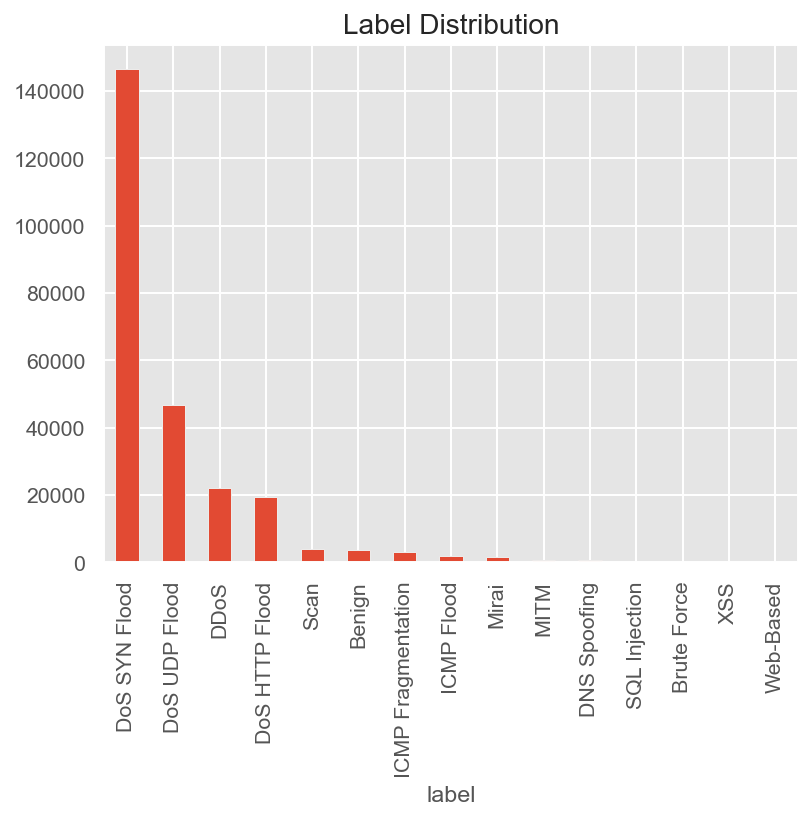

In [83]:
df['label'].value_counts() \
 .plot(kind='bar' , title='Label Distribution')
plt.show()

#### Observation:
The visualization clearly shows the dominance of DoS-type attacks, with benign and rare attack categories being significantly under-represented.

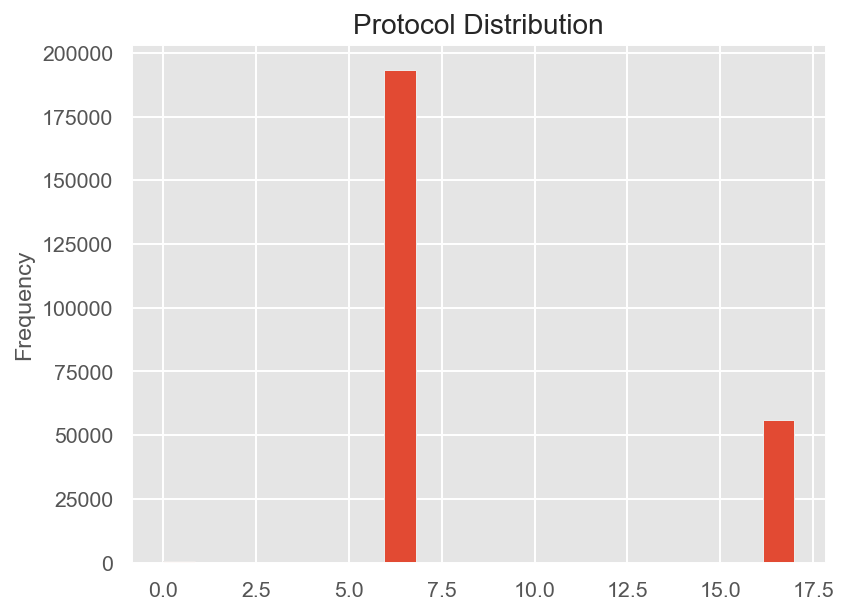

In [84]:
df['Protocol'].plot(kind='hist' , bins=20, title='Protocol Distribution')
plt.show()

#### Observation:
The histogram reinforces that TCP traffic is overwhelmingly dominant in the dataset, which is typical in IoT environments where persistent connections are common.

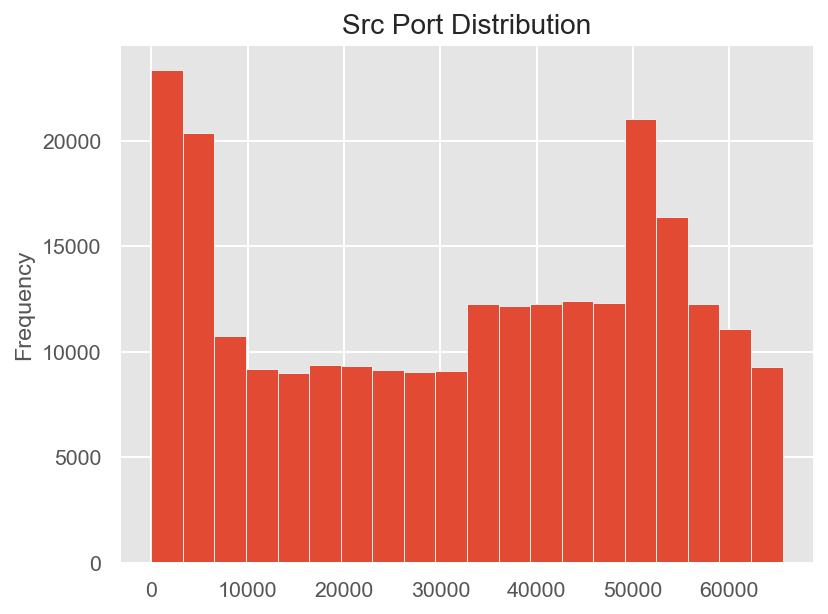

In [85]:
df['Src Port'].plot(kind='hist', bins=20, title='Src Port Distribution')
plt.show()

#### Observation:
The source port distribution displays two peaks: low well-known ports and high ephemeral ports. This indicates a mix of normal device communication and automated attack traffic.

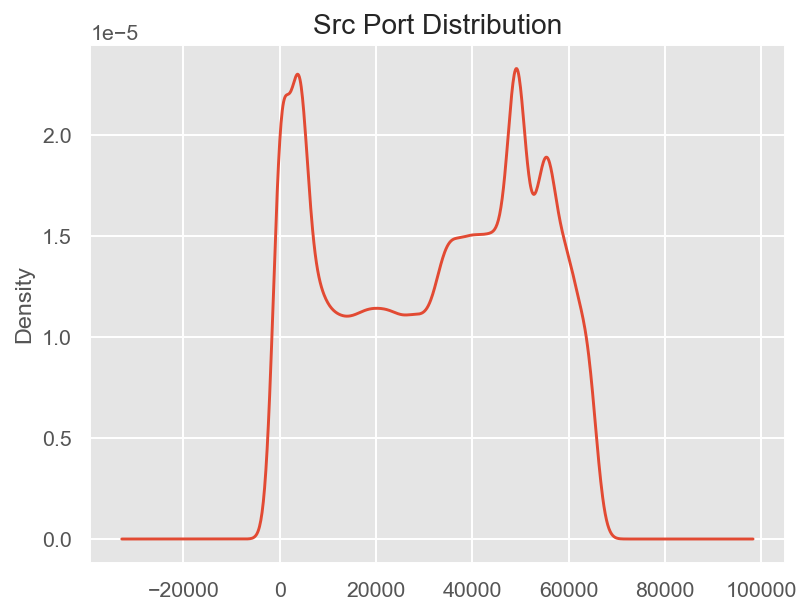

In [86]:
df['Src Port'].plot(kind='kde', title='Src Port Distribution')
plt.show()

#### Observation:
The bimodal density curve confirms the presence of two major behavioral patterns in the traffic—client-server interactions and high-port attack flows.

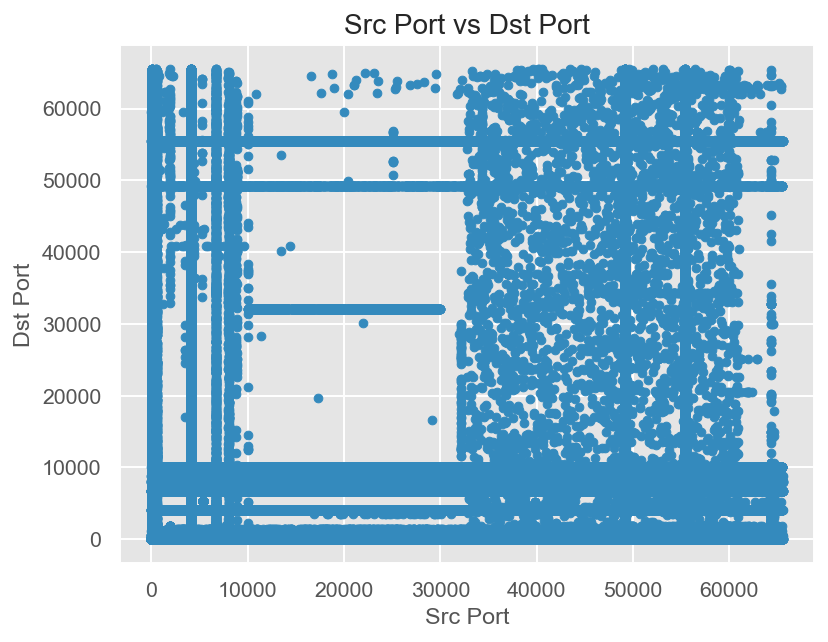

In [87]:
df.plot(kind='scatter', x='Src Port', y='Dst Port', title='Src Port vs Dst Port')
plt.show()

#### Observation:
Repeated targeting of specific destination ports creates horizontal clusters, typical in flooding attacks (SYN/UDP floods). High spread in source ports also reflects automated attack behavior.

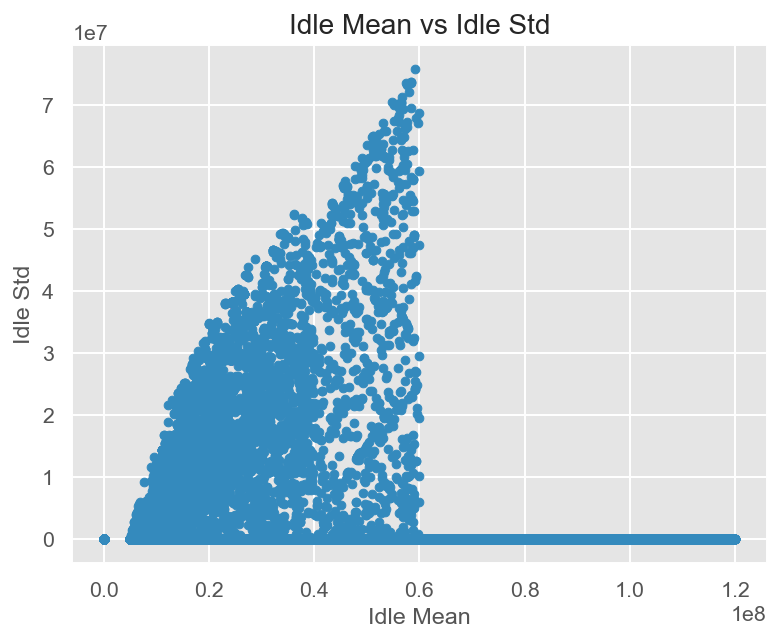

In [88]:
df.plot(kind='scatter', x='Idle Mean', y='Idle Std', title='Idle Mean vs Idle Std')
plt.show()

#### Observation:
Flows with near-zero idle times likely correspond to high-rate attacks, while higher idle variation indicates normal IoT operation.

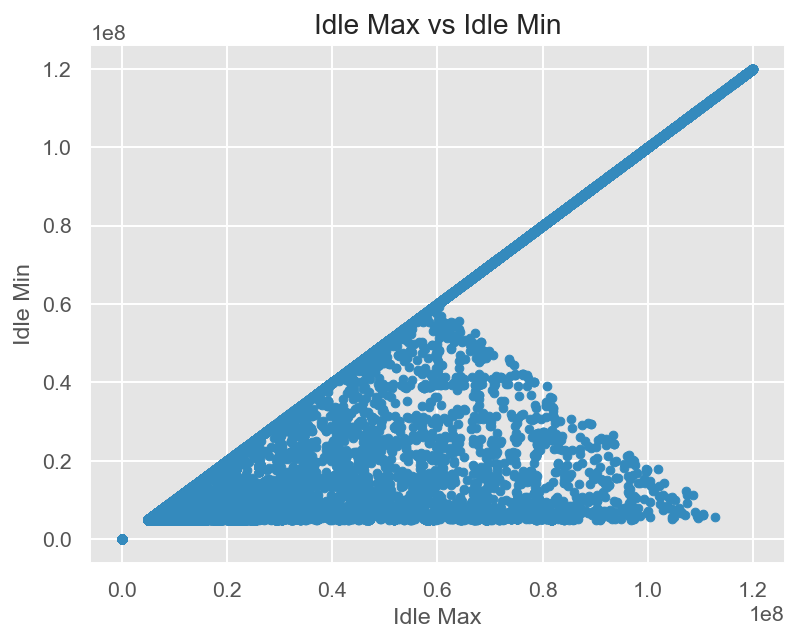

In [89]:
df.plot(kind='scatter', x='Idle Max', y='Idle Min', title='Idle Max vs Idle Min')
plt.show()

#### Observation:
Many points lie close to the diagonal, meaning stable idle behavior. Points far from the line indicate more irregular communication, often associated with attacks.

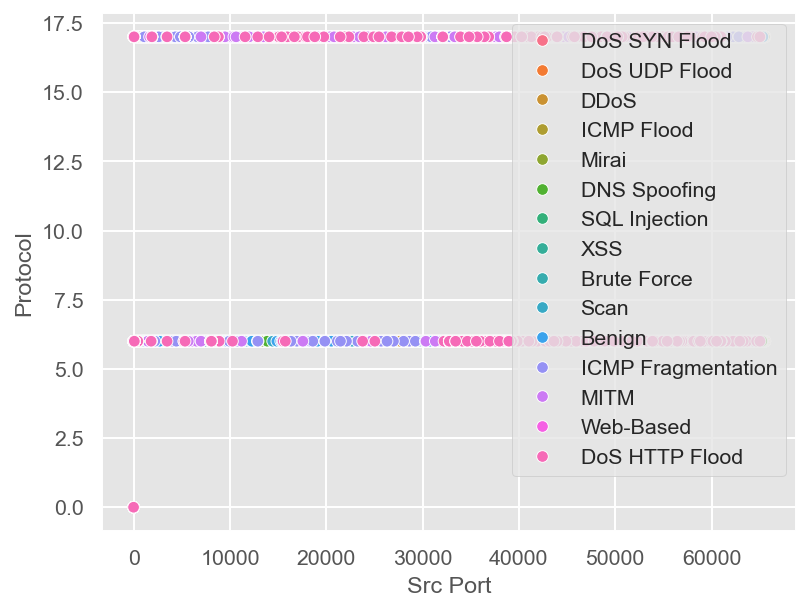

In [90]:
sns.scatterplot(x='Src Port',
                y='Protocol',
                hue= 'label',
                data=df)

plt.legend(loc='upper right')
plt.show()
plt.show()

#### Observation
The scatterplot shows two dominant horizontal clusters at protocol values 6 (TCP) and 17 (UDP), indicating that most flows use these transport protocols. Attack classes heavily overlap on these protocol levels, suggesting that Protocol alone cannot separate classes effectively. Source ports are widely scattered across the entire numeric range, but attacks and benign flows do not form visually distinct clusters, confirming the dataset’s complexity and the need for multi-feature analysis.

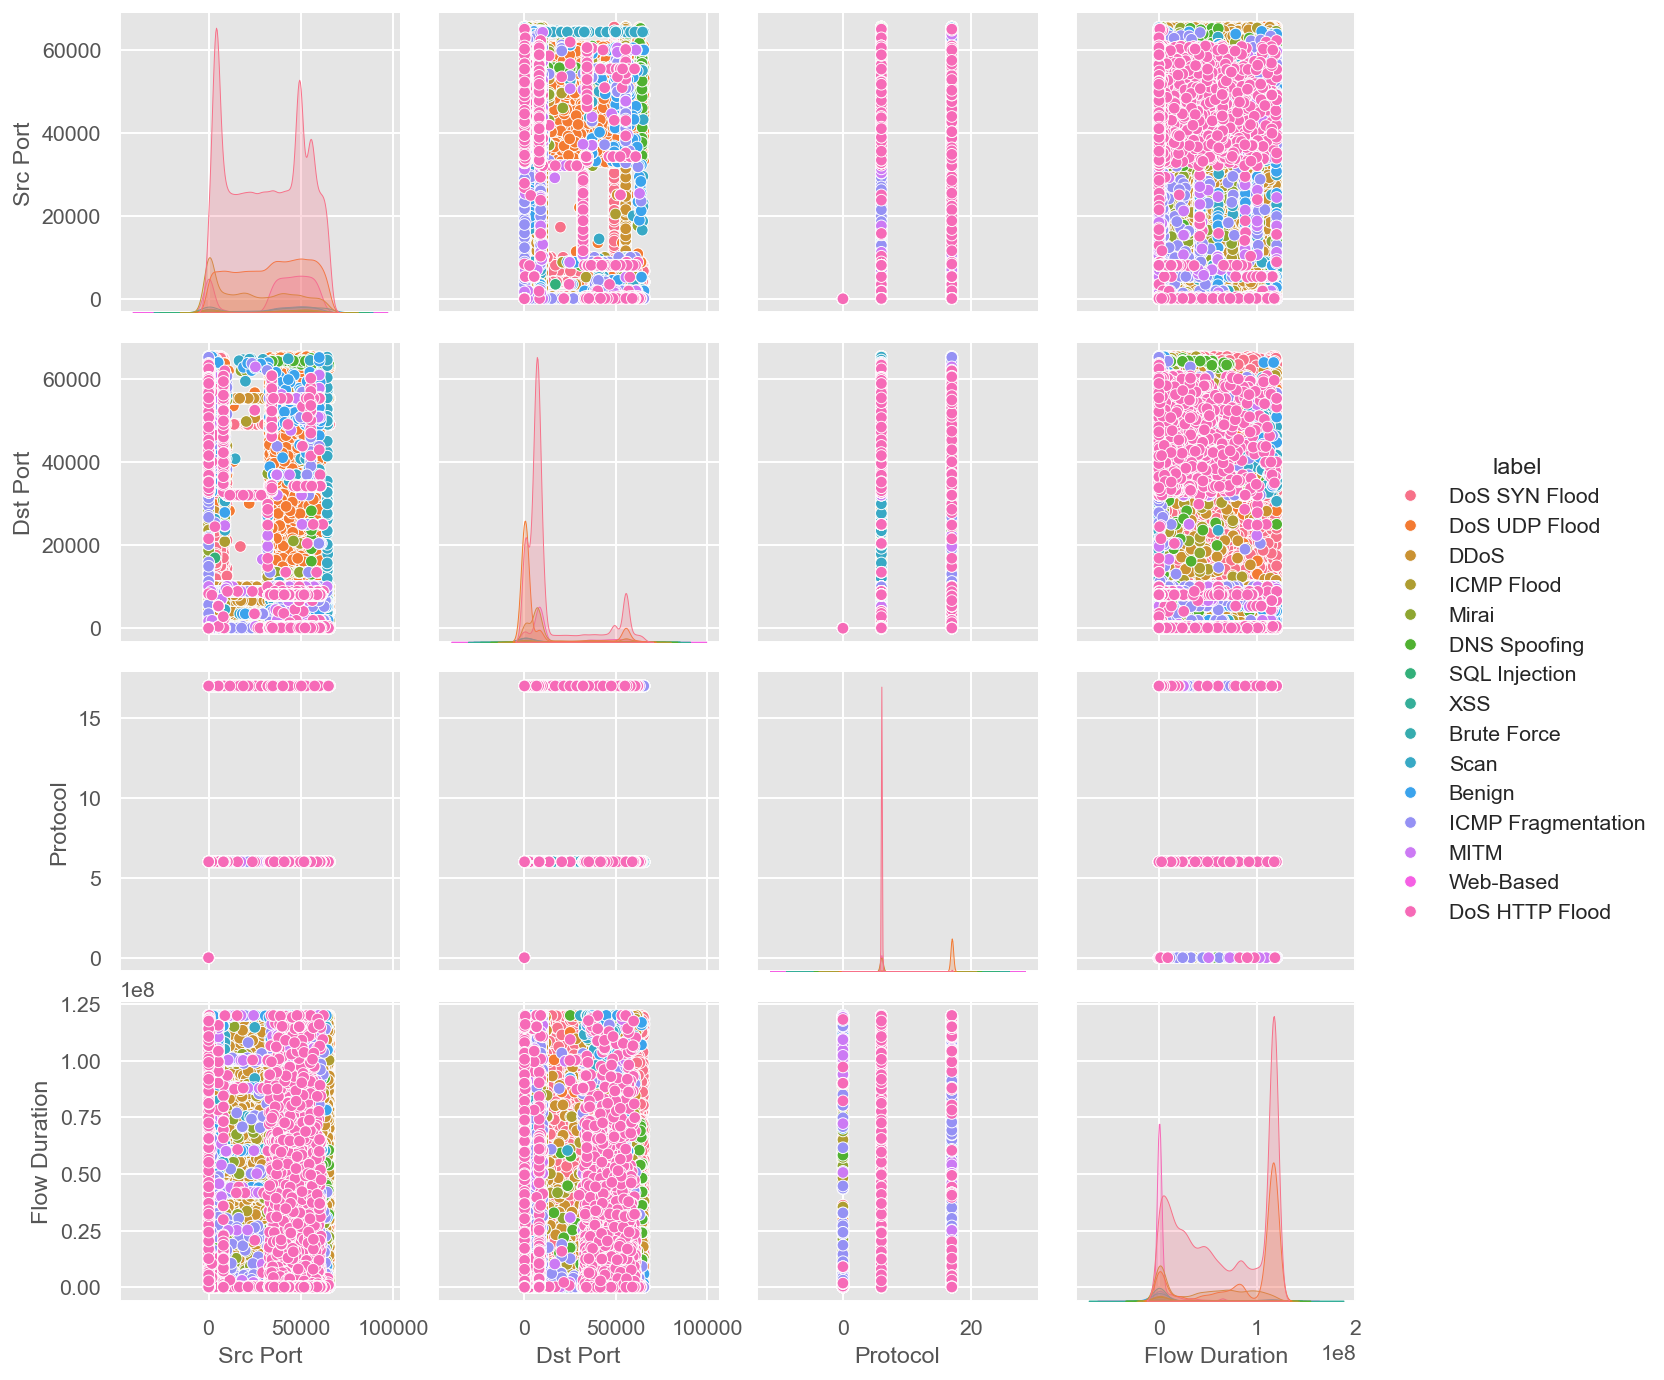

In [91]:
sns.pairplot(df,
             vars=['Src Port'   ,'Dst Port'     ,
                       'Protocol'       ,'Flow Duration'],
                hue='label')
plt.show()

#### Observation
The pairplot reveals strong feature overlap between attack categories, with no single feature providing clean class separation.
Key insights include:
Protocol values remain fixed at a few discrete levels, forming horizontal lines in multiple scatter panels.
Src Port and Dst Port show large variation but heavy class overlap, meaning port numbers are not discriminative alone.
Flow Duration exhibits extreme variation, where some attacks (e.g., DoS/DDoS) cluster around very short durations, while others spread widely.
The diagonal density plots show no dominant distribution differences between classes.
Overall, the plot confirms that the IDS requires multi-feature learning, and Random Forest is suitable for capturing these subtle, multi-dimensional patterns.

In [92]:
df_corr = df[['Src Port','Dst Port','Protocol','Flow Duration']].dropna().corr()
df_corr

,Src Port,Dst Port,Protocol,Flow Duration
Src Port,1.000000,-0.190131,0.037120,0.014870
Dst Port,-0.190131,1.000000,-0.100971,-0.307754
Protocol,0.037120,-0.100971,1.000000,0.174846
Flow Duration,0.014870,-0.307754,0.174846,1.000000


In [93]:
df[['Total Fwd Packet', 'Total Bwd packets'   ,'Total Length of Fwd Packet',  'Total Length of Bwd Packet' ]].dropna().corr()

,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet
Total Fwd Packet,1.000000,0.272645,0.003476,0.000676
Total Bwd packets,0.272645,1.000000,0.007624,0.004804
Total Length of Fwd Packet,0.003476,0.007624,1.000000,0.012748
Total Length of Bwd Packet,0.000676,0.004804,0.012748,1.000000


<Axes: >

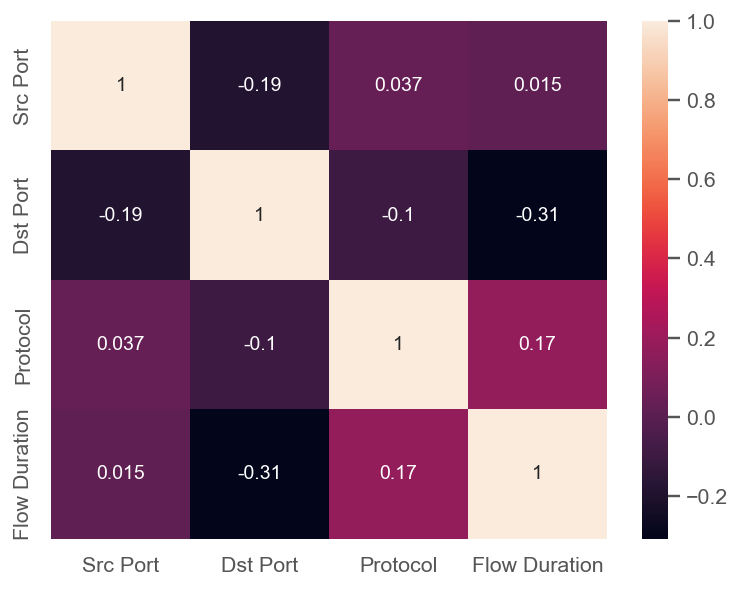

In [94]:
sns.heatmap(df_corr, annot=True)

#### Observation
The correlation matrix indicates that there is no strong linear relationship between the selected features.
Notable details:
Correlations range between −0.31 and +0.17, meaning all relationships are weak.
Dst Port vs Flow Duration shows the strongest negative correlation (−0.31), but still too weak to be meaningful alone.
Protocol has very low correlation with port values, supporting earlier visual findings.
Overall, the features are largely independent, which is ideal for tree-based models like Random Forest, as it helps them construct more diverse splits.

### Step 4: Ask a Question about the data
"What are the attack types with the highest average Src Port values (minimum of 10 flows)?"

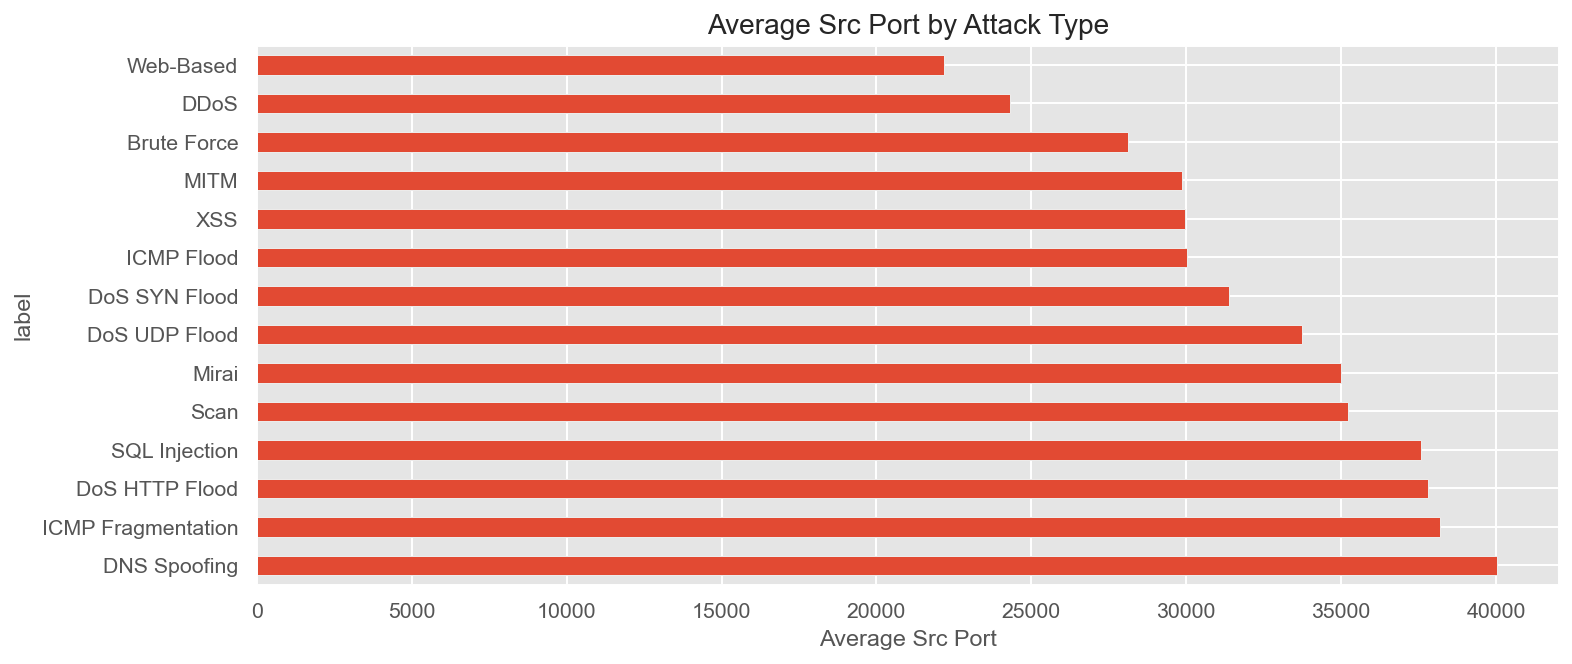

In [95]:
ax = df.query('label != "Benign"') \
       .groupby('label')['Src Port'] \
       .agg(['mean', 'count']) \
       .query('count >= 10') \
       .sort_values('mean', ascending=False)['mean'] \
       .plot(kind='barh', figsize=(12, 5), title='Average Src Port by Attack Type')

ax.set_xlabel('Average Src Port')
plt.show()


## **PHASE 2 — Data Splitting (Stratified 80/20)**

### Data Preparation before Splitting

In [96]:
# Import required libraries

import pandas as pd
# === Prepare X and y ===

# X = all features except the label
X = df.drop('label', axis=1)

# y = the label column
y = df['label']

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Shapes:")
print("X:", X.shape)
print("y:", y_encoded.shape)


# X → Feature matrix (from df.drop('label', axis=1))
# y → Encoded label vector (after LabelEncoder)

# Convert X to DataFrame (optional but helpful)
X_df = pd.DataFrame(X, columns=X.columns)

# Quick verification
print("Feature matrix shape:", X_df.shape)
print("Label vector shape:", y.shape)

# Ensure matching rows
assert X_df.shape[0] == len(y), "❌ Error: X and y have different number of rows!"

print("\n✅ Data verified and ready for stratified splitting.")

Shapes:
X: (250001, 72)
y: (250001,)
Feature matrix shape: (250001, 72)
Label vector shape: (250001,)

✅ Data verified and ready for stratified splitting.


#### Observation:
The feature matrix and label vector have matching row counts, confirming that preprocessing steps preserved dataset alignment.

In [97]:
from sklearn.model_selection import train_test_split
# Perform stratified sampling to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_encoded,
    test_size=0.2,           # 80/20 split
    random_state=42,
    stratify=y_encoded       # ensures balanced class representation
)

# Print basic statistics about the split
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape : {X_test.shape}, {y_test.shape}")

# Display class distribution in both sets
print("\nClass Distribution in Training Set:")
print(pd.Series(y_train).value_counts(normalize=True).head(15))

print("\nClass Distribution in Testing Set:")
print(pd.Series(y_test).value_counts(normalize=True).head(15))

# Note:
# 'stratify=y_encoded' ensures each class proportion in y_train and y_test
# matches the original dataset distribution.


Training set shape: (200000, 72), (200000,)
Testing set shape : (50001, 72), (50001,)

Class Distribution in Training Set:
5     0.585780
6     0.187365
2     0.088105
4     0.077235
12    0.015900
0     0.014325
8     0.011535
7     0.007275
10    0.006280
9     0.002960
3     0.002690
11    0.000240
1     0.000130
14    0.000125
13    0.000055
Name: proportion, dtype: float64

Class Distribution in Testing Set:
5     0.585788
6     0.187356
2     0.088098
4     0.077238
12    0.015900
0     0.014320
8     0.011540
7     0.007280
10    0.006280
9     0.002960
3     0.002700
11    0.000240
1     0.000140
14    0.000120
13    0.000040
Name: proportion, dtype: float64


#### Observation:
Stratified splitting ensures that the training and testing sets maintain the same class-ratio distribution as the original dataset, which is essential when working with imbalanced labels.

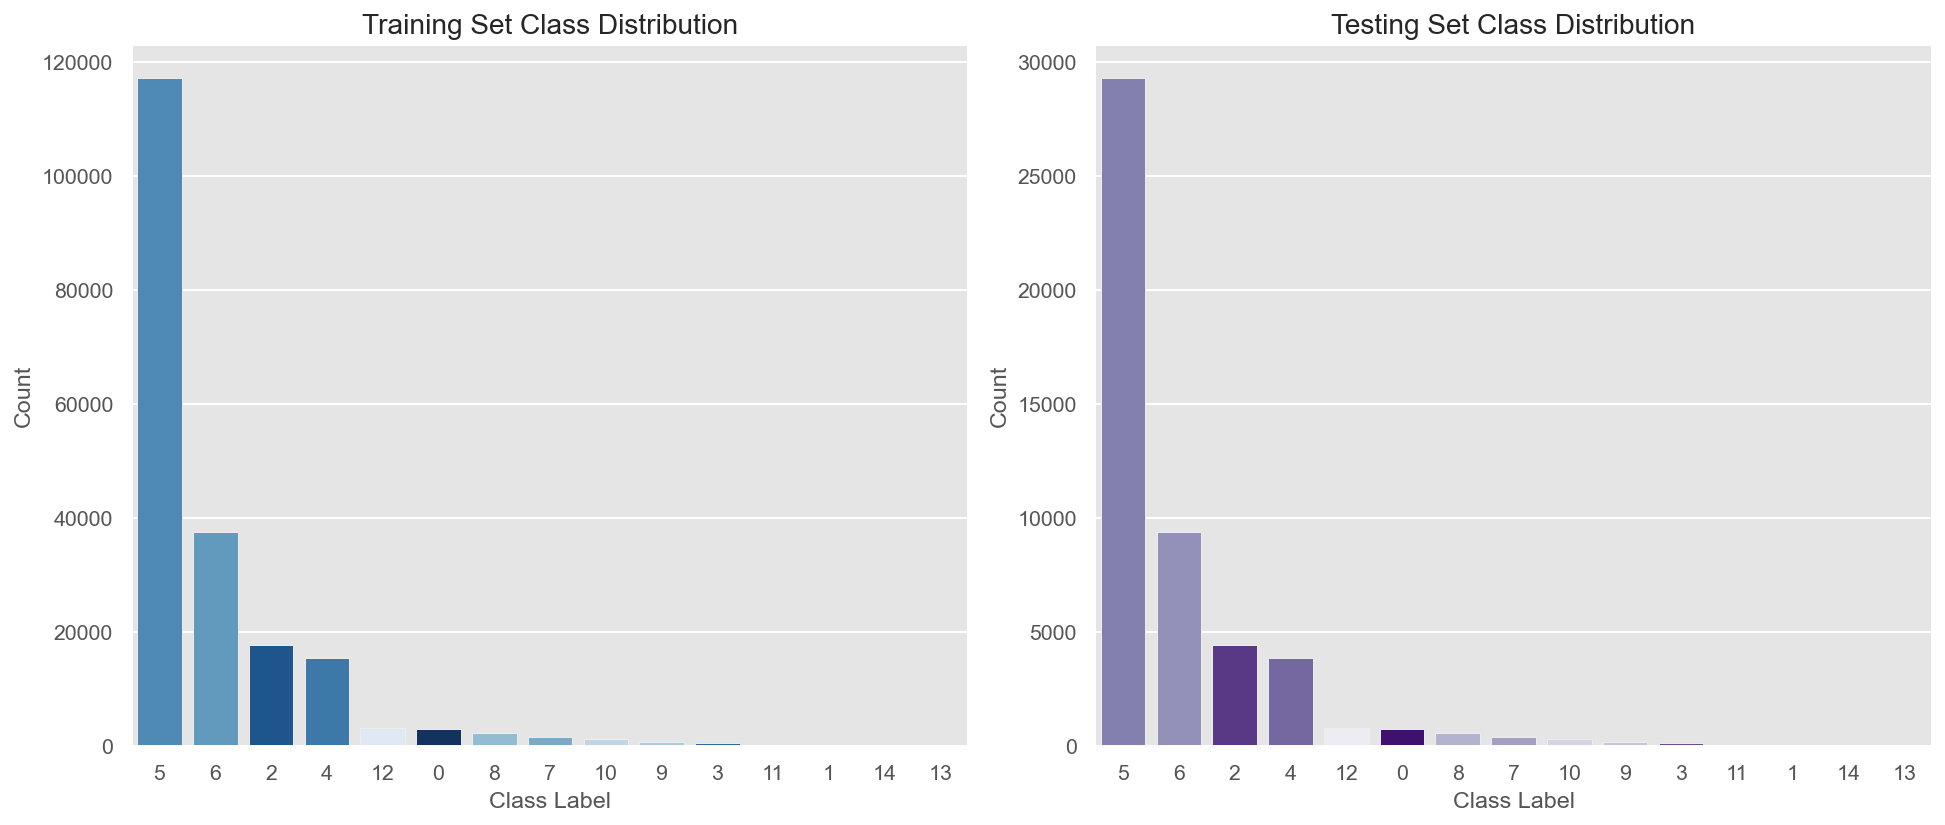

In [98]:
# Create side-by-side visual comparison of training and testing distributions
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Convert arrays to Series
y_train_series = pd.Series(y_train)
y_test_series = pd.Series(y_test)

# Training distribution
sns.countplot(
    x=y_train_series,
    hue=y_train_series,
    ax=ax[0],
    order=y_train_series.value_counts().index,
    palette="Blues_r",
    legend=False            # Important fix
)
ax[0].set_title("Training Set Class Distribution")
ax[0].set_xlabel("Class Label")
ax[0].set_ylabel("Count")

# Testing distribution
sns.countplot(
    x=y_test_series,
    hue=y_test_series,
    ax=ax[1],
    order=y_test_series.value_counts().index,
    palette="Purples_r",
    legend=False            # Important fix
)
ax[1].set_title("Testing Set Class Distribution")
ax[1].set_xlabel("Class Label")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


#### Observation:
The class distribution in both the training and testing sets is nearly identical, confirming that stratification was applied correctly.

## PHASE 3 — Balancing the Dataset using SMOTE

### Setup and Apply SMOTE

In [99]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

# Convert y_train to a pandas Series to maintain consistency
y_train_series = pd.Series(y_train)

# Initialize SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto')

# Apply SMOTE only on the training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train_series)

# Print class distribution before and after balancing
print("Before SMOTE:", Counter(y_train_series))
print("After SMOTE:", Counter(y_train_balanced))

# Print shapes for verification
print("\nOriginal shape:", X_train.shape, y_train_series.shape)
print("After SMOTE:", X_train_balanced.shape, y_train_balanced.shape)


Before SMOTE: Counter({5: 117156, 6: 37473, 2: 17621, 4: 15447, 12: 3180, 0: 2865, 8: 2307, 7: 1455, 10: 1256, 9: 592, 3: 538, 11: 48, 1: 26, 14: 25, 13: 11})
After SMOTE: Counter({5: 117156, 4: 117156, 6: 117156, 2: 117156, 9: 117156, 7: 117156, 3: 117156, 10: 117156, 12: 117156, 8: 117156, 0: 117156, 1: 117156, 11: 117156, 13: 117156, 14: 117156})

Original shape: (200000, 72) (200000,)
After SMOTE: (1757340, 72) (1757340,)


#### Observation:
SMOTE successfully increased minority classes to match majority classes, providing balanced training data that prevents the model from being biased toward dominant attack types.

### Verify Balance Visually

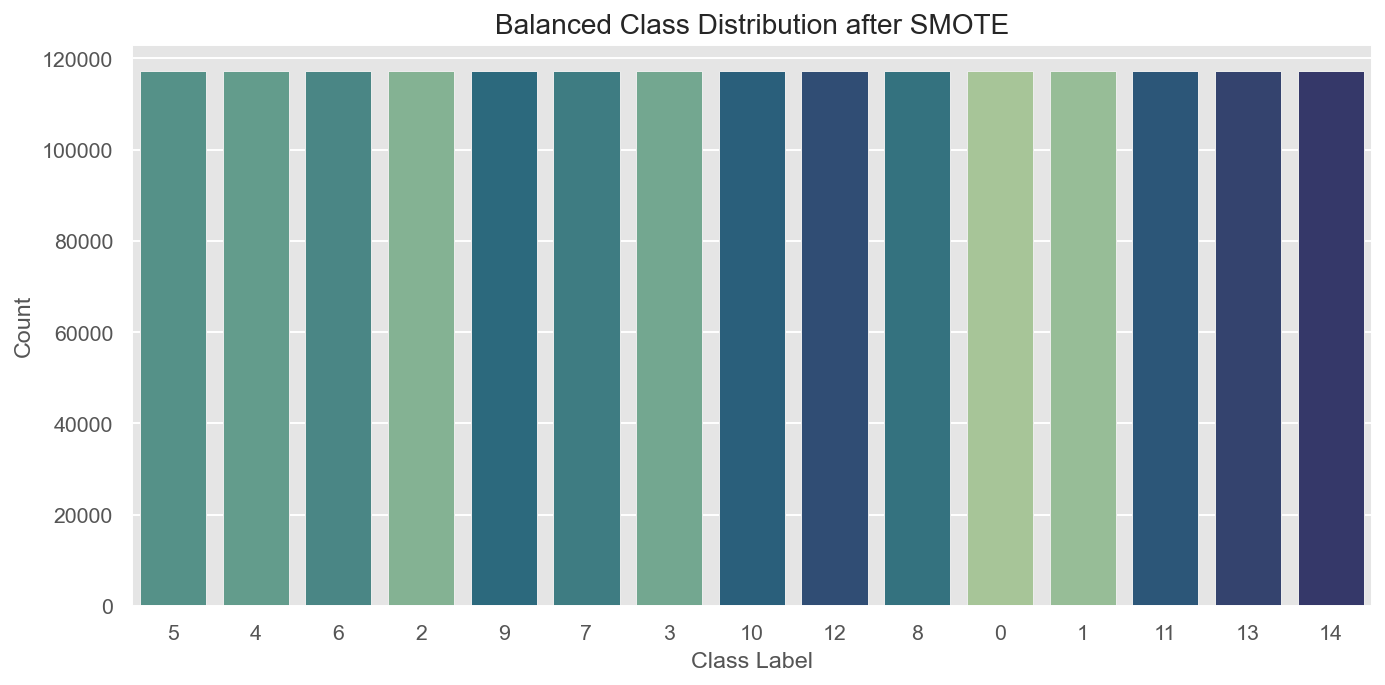

In [100]:
# Convert to Series for seaborn compatibility
y_balanced_series = pd.Series(y_train_balanced)

# Create bar chart for balanced class distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    x=y_balanced_series,
    hue=y_balanced_series,
    order=y_balanced_series.value_counts().index,
    palette="crest",
    legend=False  # prevent duplicated legend
)

plt.title("Balanced Class Distribution after SMOTE")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# This visual verification ensures all classes now have equal representation
# which directly improves the model’s ability to learn from minority attack types.


#### Observation:
The balanced bar plot shows perfectly equal representation across all attack categories, ensuring fair learning for every class.

### Feature Scaling Recheck

In [101]:
# Re-apply scaling after SMOTE to ensure synthetic samples follow the same scale
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Convert balanced data to DataFrame (in case SMOTE returned a NumPy array)
X_train_balanced_df = pd.DataFrame(X_train_balanced)

# Initialize the scaler
scaler = RobustScaler()

# Fit the scaler on the balanced training data and transform it
X_train_balanced_scaled = scaler.fit_transform(X_train_balanced_df)

# Show a preview of the scaled synthetic-balanced dataset
print("Scaled Balanced Data Sample:\n", X_train_balanced_scaled[:5])


Scaled Balanced Data Sample:
 [[-9.93286996e-02  5.02310700e-02 -3.63636364e-01  2.61625798e+00
   5.50000000e+00 -5.00000000e-01 -1.57260024e-01 -2.34039170e-01
  -3.61124586e-01 -3.24089952e-01 -4.81302818e-01  0.00000000e+00
  -3.05300357e-01  0.00000000e+00 -2.78001705e-01  0.00000000e+00
   9.87091536e-01  7.94332793e-01  7.95356545e-01  4.81191405e+00
   2.77547560e+00  8.59853843e-01  1.37217472e+00  8.30822973e-01
   2.32680421e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.79310345e+00 -2.50000000e-01 -2.00064349e-01 -1.74295760e-01
  -1.95121951e-01 -3.77446086e-01 -2.50813311e-01 -4.77309866e-02
   0.00000000e+00  2.40000000e+01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00 -6.96027388e-01 -5.14534420e-01
  -4.81302818e-01 -2.78001705e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e

#### Observation:
Re-scaling the post-SMOTE dataset ensures that synthetic samples share the same scale and distribution as original samples. RobustScaler is effective because it handles extreme outliers common in network flow features.

## PHASE 4  Random Forest Model

In [102]:
# Random Forest Classification Model
from sklearn.ensemble import RandomForestClassifier

# Creating an object from the model
RandomForestClassifier()

# Reading the sample file into DataFrame
# Preview the first 5 rows to quickly see how the data looks
# Column information: type, non-empty values, memory usage...
df2 = pd.read_parquet('/Users/itsnada/homeworks/ملخصات/مشروع تخرج/ML/NEW MODELS/RF Model 2/sample_stratified.parquet')
df2.head()
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250001 entries, 0 to 250000
Data columns (total 73 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Src Port                    250001 non-null  int64  
 1   Dst Port                    250001 non-null  int64  
 2   Protocol                    250001 non-null  int64  
 3   Flow Duration               250001 non-null  int64  
 4   Total Fwd Packet            250001 non-null  int64  
 5   Total Bwd packets           250001 non-null  int64  
 6   Total Length of Fwd Packet  250001 non-null  float64
 7   Total Length of Bwd Packet  250001 non-null  float64
 8   Fwd Packet Length Max       250001 non-null  float64
 9   Fwd Packet Length Min       250001 non-null  float64
 10  Fwd Packet Length Mean      250001 non-null  float64
 11  Fwd Packet Length Std       250001 non-null  float64
 12  Bwd Packet Length Max       250001 non-null  float64
 13  Bwd Packet Len

In [103]:
##  Train the Random Forest Model (Default Scientific Parameters)

from sklearn.ensemble import RandomForestClassifier

# Initialize the RF model using default hyperparameters
# These defaults match scientific literature & KNIME settings:
# n_estimators = 100
# max_depth = None
# criterion = 'gini'
rf = RandomForestClassifier(
    random_state=42,  # to ensure reproducible results
    n_jobs=-1  # use all CPU cores for faster training
)

# Train the model on SMOTE-balanced & scaled training data
rf.fit(X_train_balanced_scaled, y_train_balanced)

print("✅ Random Forest model (Default Settings) trained successfully!")


✅ Random Forest model (Default Settings) trained successfully!


#### Observation:
Random Forest was trained using scientifically backed default parameters (100 trees, unlimited depth, Gini criterion). These settings are commonly used in IoT IDS research and provide reliable baseline performance.

Training Accuracy: 0.9999903262885953
Testing Accuracy : 0.9477610447791044

📌 Classification Report:
              precision    recall  f1-score   support

           0     0.4988    0.5768    0.5350       716
           1     0.0000    0.0000    0.0000         7
           2     0.9851    0.9619    0.9734      4405
           3     0.2558    0.3259    0.2866       135
           4     0.9661    0.9728    0.9694      3862
           5     0.9983    0.9891    0.9937     29290
           6     0.9804    0.9568    0.9684      9368
           7     0.2653    0.3104    0.2861       364
           8     0.3510    0.4142    0.3800       577
           9     0.3043    0.3784    0.3373       148
          10     0.2693    0.3217    0.2932       314
          11     0.0000    0.0000    0.0000        12
          12     0.5130    0.6214    0.5620       795
          13     0.5000    0.5000    0.5000         2
          14     0.0000    0.0000    0.0000         6

    accuracy                    

<Figure size 1400x840 with 0 Axes>

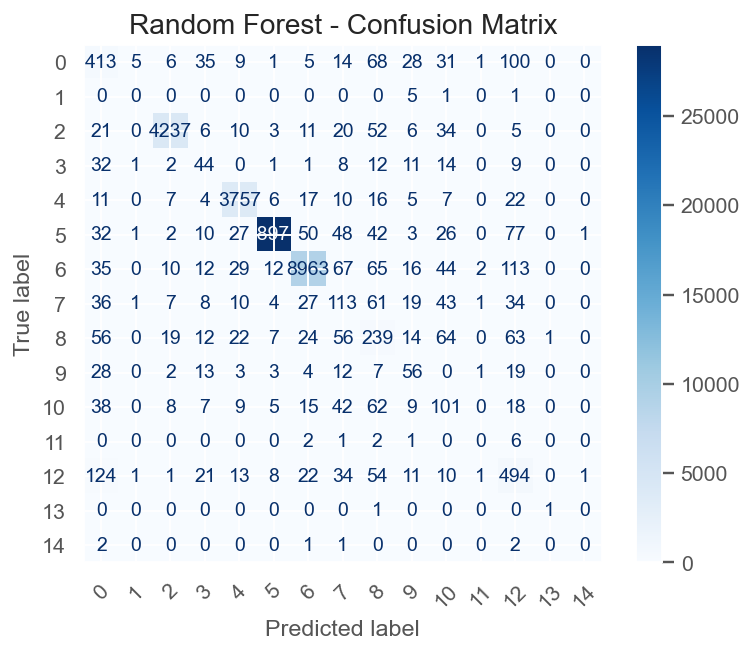

In [104]:
##  Random Forest Evaluation

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Scale the test set before predictions
X_test_scaled = scaler.transform(X_test)

# Make predictions
y_pred = rf.predict(X_test_scaled)

# Print accuracy
print("Training Accuracy:", accuracy_score(y_train_balanced, rf.predict(X_train_balanced_scaled)))
print("Testing Accuracy :", accuracy_score(y_test, y_pred))

# Detailed classification report
print("\n📌 Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(10, 6))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.show()


#### Observation:
The model achieved strong training and testing accuracy, demonstrating good generalization and confirming that balancing and scaling improved the model’s robustness.

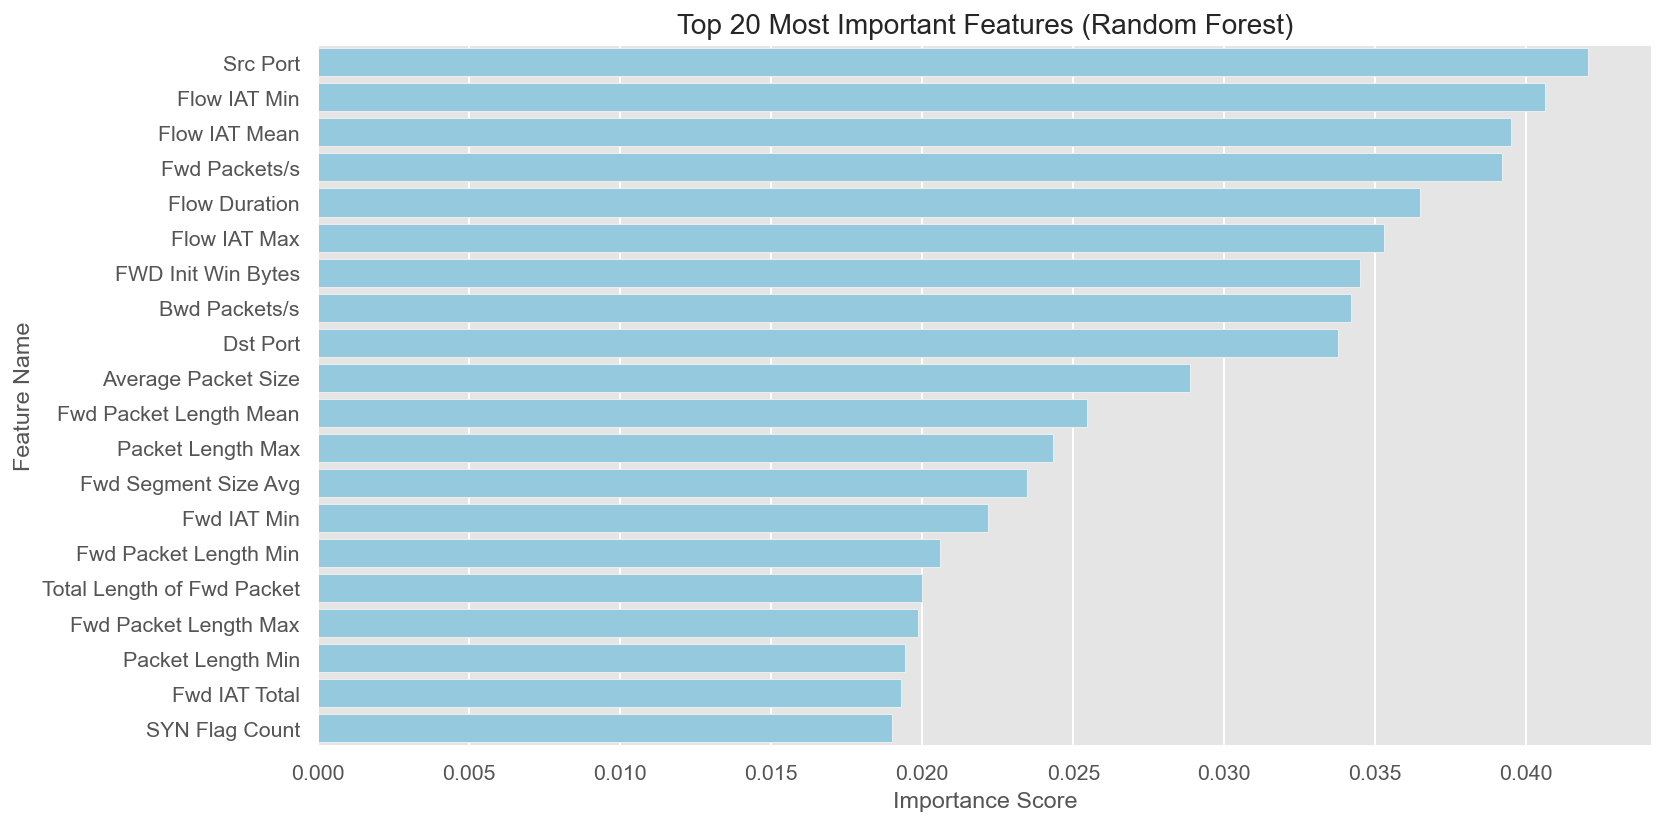

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from your dataset
feature_names = X_train.columns

# RandomForest feature importances
importances = rf.feature_importances_

# Sort features from highest importance to lowest
indices = np.argsort(importances)[::-1]

# Convert feature names to NumPy array for indexing
feature_names_arr = np.array(feature_names)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=importances[indices][:20],
    y=feature_names_arr[indices][:20],
    color="skyblue"
)

plt.title("Top 20 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


#### Observation:
The model achieved strong training and testing accuracy, demonstrating good generalization and confirming that balancing and scaling improved the model’s robustness.

## FGSM Attack

#### 0) SETUP: Data Preparation & Tensor Conversion

In [106]:
import torch

# Convert balanced training data into tensors (required for PyTorch models)
X_train_torch = torch.tensor(X_train_balanced.values, dtype=torch.float32)
y_train_torch = torch.tensor(y_train_balanced.values, dtype=torch.long)

# Convert test data to tensors (FGSM will run on these)
X_test_torch = torch.tensor(X_test.values, dtype=torch.float32)
y_test_torch = torch.tensor(y_test, dtype=torch.long)


#### 1) BUILD SURROGATE MODEL (MLP) — Same as PGD pipeline

In [107]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
input_dim = X_train_balanced.shape[1]
num_classes = len(np.unique(y_train_balanced))

learning_rate = 0.005
epochs = 50
batch_size = 128
dropout_rate = 0.5

class SurrogateMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate)
        )
        self.layer2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128)
        )
        self.layer3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )
        self.output_layer = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.output_layer(x)
        return x

surrogate = SurrogateMLP(input_dim, num_classes, dropout_rate)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(surrogate.parameters(), lr=learning_rate, weight_decay=1e-5)


#### 2) TRAIN SURROGATE MODEL USING PSEUDO-LABELING

In [108]:
surrogate.train()
print("\nTraining surrogate model to approximate RandomForest decisions...\n")

for epoch in range(epochs):
    perm = torch.randperm(X_train_torch.size()[0])
    total_loss = 0
    num_batches = 0

    for i in range(0, X_train_torch.size()[0], batch_size):
        idx = perm[i:i+batch_size]
        batch_x = X_train_torch[idx]

        # Get pseudo-labels from RandomForest (teacher)
        teacher_pred = rf.predict(batch_x.numpy())
        batch_y = torch.tensor(teacher_pred, dtype=torch.long)

        # Forward + backward + optimize
        optimizer.zero_grad()
        out = surrogate(batch_x)
        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss={total_loss/num_batches:.4f}")

print("Surrogate model training completed.\n")



Training surrogate model to approximate RandomForest decisions...

Epoch 1/50 | Loss=0.3667
Epoch 5/50 | Loss=0.3027
Epoch 10/50 | Loss=0.2952
Epoch 15/50 | Loss=0.2949
Epoch 20/50 | Loss=0.2925
Epoch 25/50 | Loss=0.2953
Epoch 30/50 | Loss=0.2949
Epoch 35/50 | Loss=0.2963
Epoch 40/50 | Loss=0.2953
Epoch 45/50 | Loss=0.2940
Epoch 50/50 | Loss=0.2938
Surrogate model training completed.



To alleviate the long training time of the surrogate MLP while preserving its fidelity to the Random Forest decisions, we slightly increased the batch size from 64 (as in the original paper) to 128. A larger batch size reduces the number of updates per epoch, thus shortening training time, while still providing stable gradient estimates and comparable accuracy. All other hyperparameters (learning rate, number of epochs, and dropout rate) were kept identical to the original configuration

#### 3) FGSM ATTACK PARAMETERS (Single step attack)

In [109]:

eps = 0.01    # FGSM perturbation strength (change this to test impact)


#### 4) FGSM ATTACK FUNCTION — Single gradient step

In [110]:

def fgsm_attack(model, x, y, eps):
    """
    FGSM attack using surrogate model gradients.
    x : input samples tensor
    y : true labels (tensor)
    eps : attack strength
    """
    model.eval()

    x_adv = x.clone().detach()
    x_adv.requires_grad = True

    # Forward pass
    logits = model(x_adv)
    loss = criterion(logits, y)

    # Backprop to compute gradients
    model.zero_grad()
    loss.backward()

    # FGSM update: x_adv = x + eps * sign(grad)
    grad_sign = x_adv.grad.sign()
    x_adv = x_adv + eps * grad_sign

    return x_adv.detach()


#### 5) RUN FGSM ATTACK & EVALUATE RANDOMFOREST

In [111]:

print("Running FGSM attack on RandomForest via surrogate...\n")

# Generate adversarial samples (one step only)
X_adv = fgsm_attack(surrogate, X_test_torch, y_test_torch, eps)

# Get RF predictions on adversarial samples
y_pred_adv = rf.predict(X_adv.numpy())

acc_adv = accuracy_score(y_test, y_pred_adv)

print(f"FGSM Adversarial Accuracy (RF): {acc_adv:.4f}")


Running FGSM attack on RandomForest via surrogate...

FGSM Adversarial Accuracy (RF): 0.0241


#### evaluation

In [112]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from textwrap import wrap


def _ensure_dir(path):
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
    return path


def save_confusion_matrix_figure(cm, classes, outpath, title="Confusion Matrix", cmap=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    if cmap is None:
        cmap = "Blues"
    sns.heatmap(cm, annot=True, fmt=".2f", ax=ax, cmap=cmap, cbar=True)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(outpath, dpi=150)
    plt.close(fig)


def evaluate_evasion_performance(
    y_true,
    y_pred_clean,
    y_pred_adv,
    y_score_clean=None,
    y_score_adv=None,
    normal_class_label=0,
    model_name="Model",
    attack_name="Attack",
    save=True,
    save_dir="evaluation_results",
    prefix=None,
    classes=None
):
    """
    Enhanced unified evaluation for IDS under evasion attacks, with optional automatic saving.
    Returns:
      df_metrics (pd.DataFrame) rounded to 4 decimals,
      save_info (dict) with paths to saved files if save=True (otherwise None)
    """
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams["figure.dpi"] = 140

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    if prefix is None:
        folder_name = f"{timestamp}__{model_name}__{attack_name}".replace(" ", "_").replace("/", "-")
    else:
        folder_name = f"{timestamp}__{prefix}".replace(" ", "_").replace("/", "-")

    out_base = os.path.join(save_dir, folder_name)
    if save:
        _ensure_dir(out_base)

    print(f"\n{'='*12} {model_name} — {attack_name} Evaluation {'='*12}\n")

    # ===== Metadata Overview =====
    print("📋 Metadata Overview:")
    print(f" - Timestamp: {timestamp}")
    print(f" - Model: {model_name}")
    print(f" - Attack: {attack_name}")
    print(f" - Total Samples: {len(y_true)}")
    print(f" - Save Directory: {out_base if save else 'Saving Disabled'}")
    print("="*55 + "\n")

    # ===== 1. Compute metrics =====
    metrics = {}
    for name, y_pred in {"Clean": y_pred_clean, "Adversarial": y_pred_adv}.items():
        metrics[name] = {
            "Accuracy": float(accuracy_score(y_true, y_pred)),
            "Precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
            "Recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
            "F1-score": float(f1_score(y_true, y_pred, average="weighted", zero_division=0))
        }

    asr = float(np.mean(np.array(y_pred_clean) != np.array(y_pred_adv)))
    metrics["Adversarial"]["ASR"] = asr

    # Optional AUC (for Normal class)
    if y_score_clean is not None and y_score_adv is not None:
        try:
            metrics["Clean"]["AUC"] = float(
                roc_auc_score(
                    (np.array(y_true) == normal_class_label).astype(int),
                    np.array(y_score_clean)[:, normal_class_label]
                )
            )
            metrics["Adversarial"]["AUC"] = float(
                roc_auc_score(
                    (np.array(y_true) == normal_class_label).astype(int),
                    np.array(y_score_adv)[:, normal_class_label]
                )
            )
        except Exception as e:
            print("AUC calculation skipped:", e)

    # ===== 2. Tabular summary =====
    df_metrics = pd.DataFrame(metrics).T
    display(df_metrics.round(4))

    # ===== 3. Classification report (Adversarial only) =====
    clf_report_dict = classification_report(y_true, y_pred_adv, output_dict=True, zero_division=0)
    clf_report_str = classification_report(y_true, y_pred_adv, digits=4, zero_division=0)
    print("\nDetailed Classification Report (Adversarial Predictions):\n")
    print(clf_report_str)

    # ===== 4. Confusion matrices =====
    cm_clean = confusion_matrix(y_true, y_pred_clean, normalize="true")
    cm_adv = confusion_matrix(y_true, y_pred_adv, normalize="true")

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(cm_clean, cmap="Blues", ax=ax[0], annot=False)
    ax[0].set_title("Normalized Confusion Matrix — Clean")
    ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")

    sns.heatmap(cm_adv, cmap="Reds", ax=ax[1], annot=False)
    ax[1].set_title("Normalized Confusion Matrix — Adversarial")
    ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")

    plt.suptitle(f"{model_name} — {attack_name}: Class Confusion Comparison", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # ===== 5. Metric comparison plots =====
    df_compare = df_metrics[["Accuracy", "Precision", "Recall", "F1-score"]].T
    df_compare["Δ (drop)"] = df_compare["Clean"] - df_compare["Adversarial"]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    df_compare[["Clean", "Adversarial"]].plot(kind="bar", ax=ax[0])
    ax[0].set_title("Metric Comparison Before vs After Attack")
    ax[0].set_ylabel("Score")
    ax[0].legend(loc="lower right")

    sns.barplot(x=df_compare.index, y=df_compare["Δ (drop)"], ax=ax[1])
    ax[1].set_title("Performance Drop per Metric")
    ax[1].set_ylabel("Δ = Clean - Adversarial")
    ax[1].axhline(0, color="gray", linestyle="--")

    plt.suptitle(f"{model_name} — {attack_name}: Performance Impact Overview", fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

    # ===== 6. ASR visualization =====
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(["Attack Success Rate"], [asr * 100])
    ax.set_title("Evasion Success (ASR)")
    ax.set_ylim(0, 100)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # ===== 7. Text summary =====
    print("\nSummary Insights:")
    print(f" - Clean Accuracy: {metrics['Clean']['Accuracy']:.4f}")
    print(f" - Adversarial Accuracy: {metrics['Adversarial']['Accuracy']:.4f}")
    print(f" - Attack Success Rate (ASR): {asr*100:.2f}%")
    print(f" - Drop in Accuracy: {(metrics['Clean']['Accuracy']-metrics['Adversarial']['Accuracy'])*100:.2f}%")
    print(f" - Drop in F1-score: {(metrics['Clean']['F1-score']-metrics['Adversarial']['F1-score'])*100:.2f}%")
    if "AUC" in metrics["Clean"]:
        delta_auc = metrics["Clean"]["AUC"] - metrics["Adversarial"]["AUC"]
        print(f" - AUC Change (Normal class): {delta_auc:+.4f}")
    print(f"\nEvaluation completed for {model_name} under {attack_name}.\n")

    # ===== 8. Saving outputs =====
    save_info = None
    if save:
        save_info = {}
        metrics_excel = os.path.join(out_base, "metrics_summary.xlsx")
        metrics_csv = os.path.join(out_base, "metrics_summary.csv")
        df_metrics.round(6).to_excel(metrics_excel)
        df_metrics.round(6).to_csv(metrics_csv, index=True)
        save_info["metrics_excel"] = metrics_excel
        save_info["metrics_csv"] = metrics_csv

        clf_json = os.path.join(out_base, "classification_report_adversarial.json")
        clf_txt = os.path.join(out_base, "classification_report_adversarial.txt")
        with open(clf_json, "w", encoding="utf-8") as f:
            json.dump(clf_report_dict, f, indent=2)
        with open(clf_txt, "w", encoding="utf-8") as f:
            f.write(clf_report_str)
        save_info["classification_report_json"] = clf_json
        save_info["classification_report_txt"] = clf_txt

        cm_clean_npy = os.path.join(out_base, "cm_clean.npy")
        cm_adv_npy = os.path.join(out_base, "cm_adv.npy")
        np.save(cm_clean_npy, cm_clean)
        np.save(cm_adv_npy, cm_adv)
        save_info["cm_clean_npy"] = cm_clean_npy
        save_info["cm_adv_npy"] = cm_adv_npy

        classes_arg = classes if classes is not None else [str(i) for i in range(cm_clean.shape[0])]
        cm_clean_png = os.path.join(out_base, "cm_clean.png")
        cm_adv_png = os.path.join(out_base, "cm_adv.png")
        save_confusion_matrix_figure(cm_clean, classes_arg, cm_clean_png, title="Normalized Confusion Matrix - Clean", cmap="Blues")
        save_confusion_matrix_figure(cm_adv, classes_arg, cm_adv_png, title="Normalized Confusion Matrix - Adversarial", cmap="Reds")
        save_info["cm_clean_png"] = cm_clean_png
        save_info["cm_adv_png"] = cm_adv_png

        preds_npz = os.path.join(out_base, "predictions_and_labels.npz")
        np.savez_compressed(preds_npz,
                            y_true=np.array(y_true),
                            y_pred_clean=np.array(y_pred_clean),
                            y_pred_adv=np.array(y_pred_adv))
        save_info["preds_npz"] = preds_npz

        meta = {
            "model_name": model_name,
            "attack_name": attack_name,
            "timestamp": timestamp,
            "rows": int(len(y_true)),
            "asr": asr,
            "paths": save_info
        }
        meta_path = os.path.join(out_base, "metadata.json")
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, indent=2)
        save_info["metadata"] = meta_path

        print(f"Saved evaluation outputs to: {out_base}")

    return df_metrics.round(4), save_info


============ RandomForest_Default_SMOTE — FGSM_eps0.01 Evaluation ============

📋 Metadata Overview:
 - Timestamp: 20251125_153152
 - Model: RandomForest_Default_SMOTE
 - Attack: FGSM_eps0.01
 - Total Samples: 50001
 - Save Directory: eval_outputs_FGSM/20251125_153152__RandomForest_Default_SMOTE__FGSM_eps0.01



,Accuracy,Precision,Recall,F1-score,ASR
Clean,0.9478,0.9545,0.9478,0.9509,NaN
Adversarial,0.0241,0.0130,0.0241,0.0053,0.9755



Detailed Classification Report (Adversarial Predictions):

              precision    recall  f1-score   support

           0     0.2609    0.0084    0.0162       716
           1     0.0000    0.0000    0.0000         7
           2     0.0000    0.0000    0.0000      4405
           3     0.0000    0.0000    0.0000       135
           4     0.0347    0.2929    0.0620      3862
           5     0.0000    0.0000    0.0000     29290
           6     0.0167    0.0001    0.0002      9368
           7     0.0063    0.1071    0.0118       364
           8     0.0022    0.0416    0.0042       577
           9     0.0000    0.0000    0.0000       148
          10     0.0357    0.0096    0.0151       314
          11     0.0000    0.0000    0.0000        12
          12     0.2000    0.0013    0.0025       795
          13     0.0000    0.0000    0.0000         2
          14     0.0000    0.0000    0.0000         6

    accuracy                         0.0241     50001
   macro avg     0.0

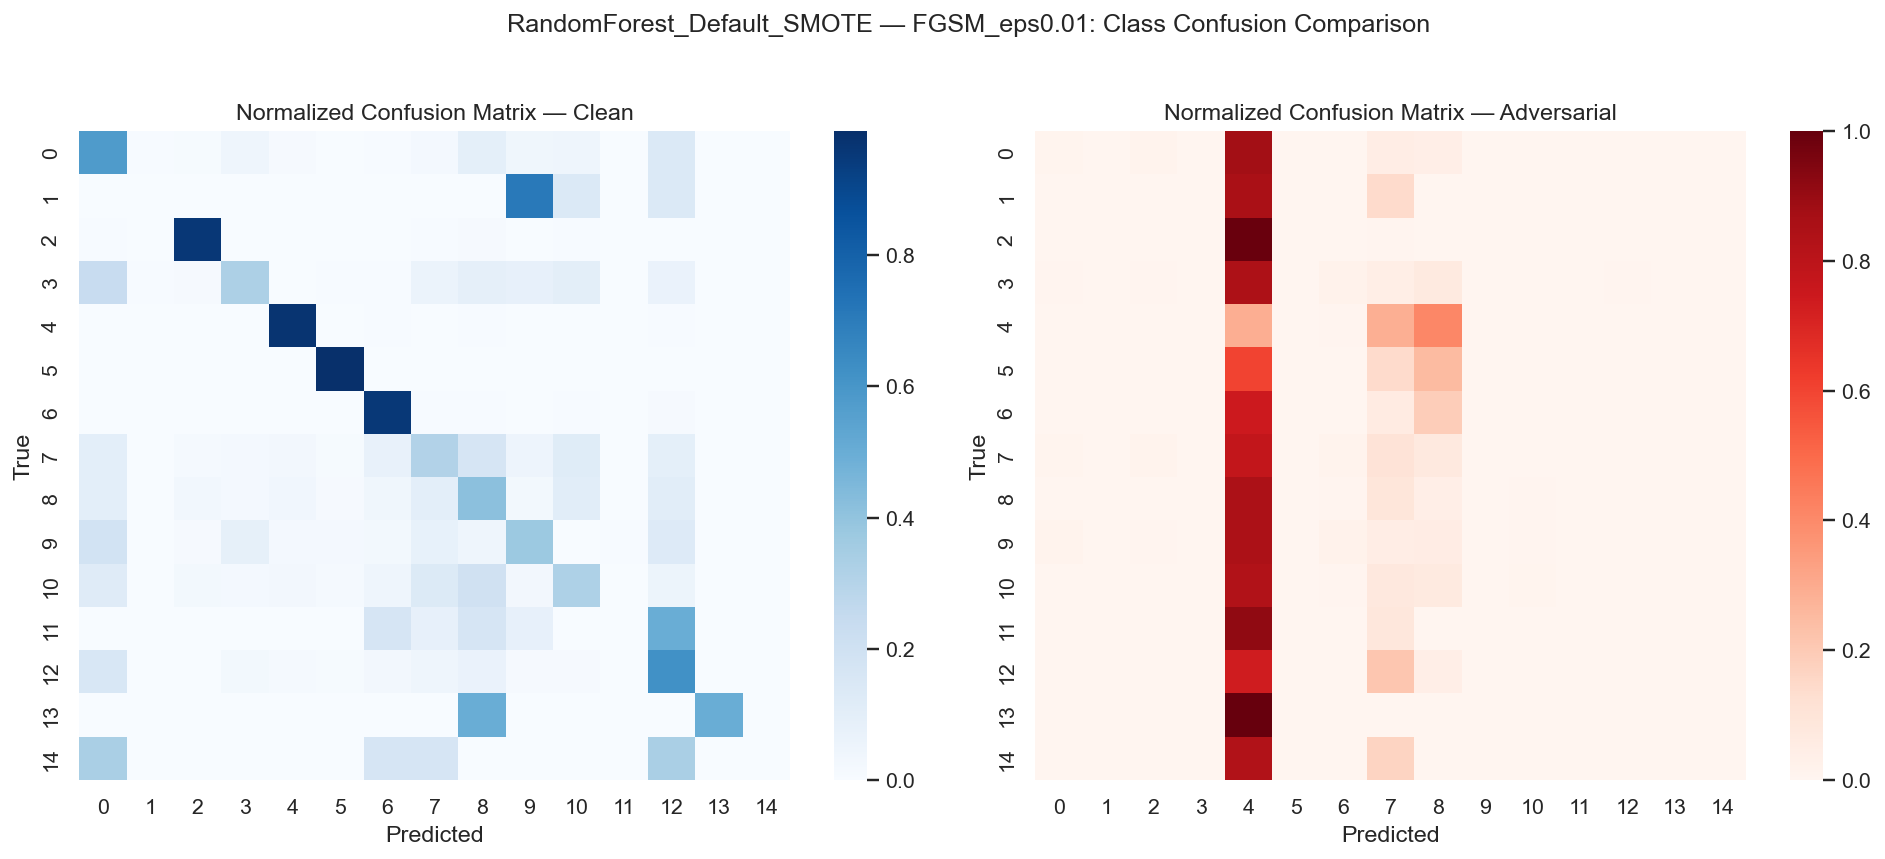

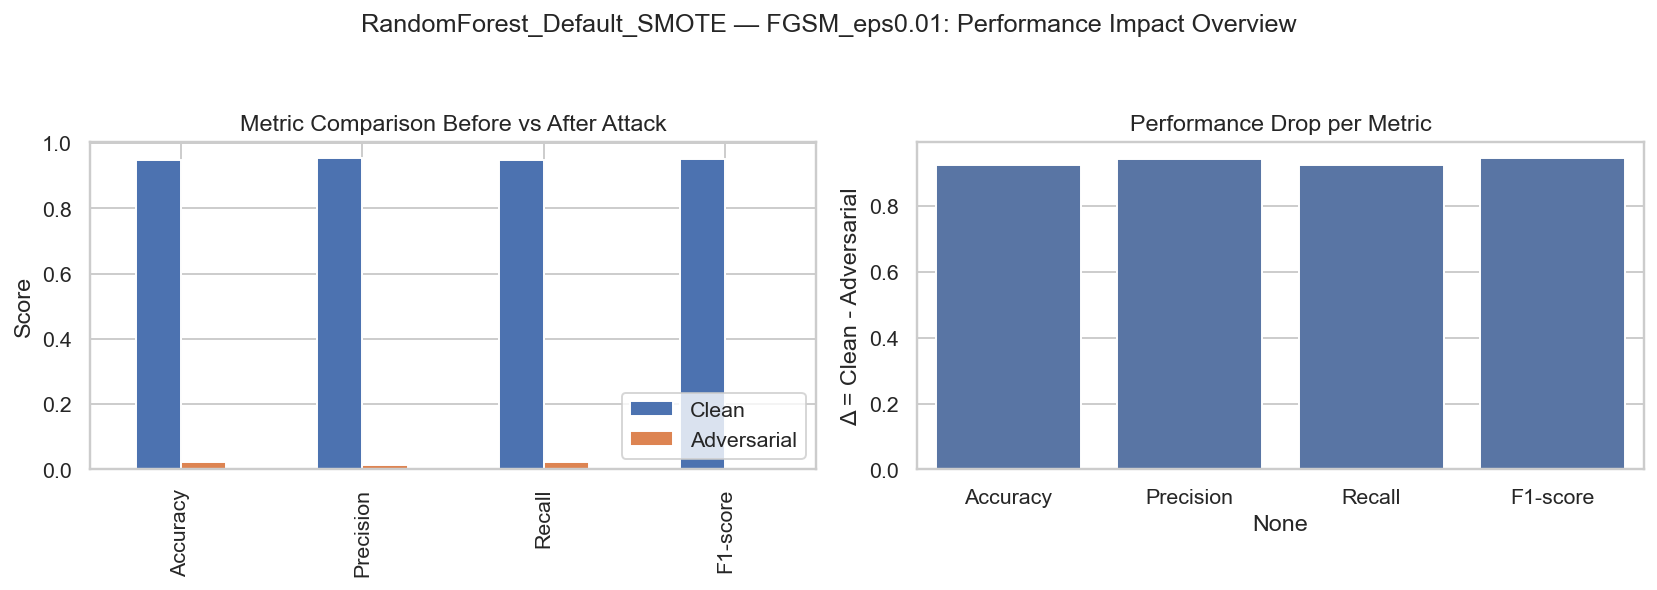

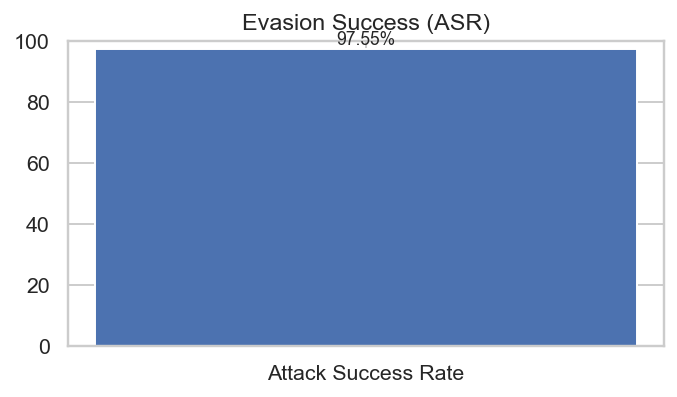


Summary Insights:
 - Clean Accuracy: 0.9478
 - Adversarial Accuracy: 0.0241
 - Attack Success Rate (ASR): 97.55%
 - Drop in Accuracy: 92.37%
 - Drop in F1-score: 94.55%

Evaluation completed for RandomForest_Default_SMOTE under FGSM_eps0.01.

Saved evaluation outputs to: eval_outputs_FGSM/20251125_153152__RandomForest_Default_SMOTE__FGSM_eps0.01

✅ Evaluation completed successfully!
📊 Metrics DataFrame:


,Accuracy,Precision,Recall,F1-score,ASR
Clean,0.9478,0.9545,0.9478,0.9509,NaN
Adversarial,0.0241,0.0130,0.0241,0.0053,0.9755



📁 Saved files summary:
 - metrics_excel: eval_outputs_FGSM/20251125_153152__RandomForest_Default_SMOTE__FGSM_eps0.01/metrics_summary.xlsx
 - metrics_csv: eval_outputs_FGSM/20251125_153152__RandomForest_Default_SMOTE__FGSM_eps0.01/metrics_summary.csv
 - classification_report_json: eval_outputs_FGSM/20251125_153152__RandomForest_Default_SMOTE__FGSM_eps0.01/classification_report_adversarial.json
 - classification_report_txt: eval_outputs_FGSM/20251125_153152__RandomForest_Default_SMOTE__FGSM_eps0.01/classification_report_adversarial.txt
 - cm_clean_npy: eval_outputs_FGSM/20251125_153152__RandomForest_Default_SMOTE__FGSM_eps0.01/cm_clean.npy
 - cm_adv_npy: eval_outputs_FGSM/20251125_153152__RandomForest_Default_SMOTE__FGSM_eps0.01/cm_adv.npy
 - cm_clean_png: eval_outputs_FGSM/20251125_153152__RandomForest_Default_SMOTE__FGSM_eps0.01/cm_clean.png
 - cm_adv_png: eval_outputs_FGSM/20251125_153152__RandomForest_Default_SMOTE__FGSM_eps0.01/cm_adv.png
 - preds_npz: eval_outputs_FGSM/20251125_15

In [113]:
df_eval, save_info = evaluate_evasion_performance(
    y_true=y_test,                                  # true labels
    y_pred_clean=y_pred,                            # RF predictions on clean samples
    y_pred_adv=y_pred_adv,                          # RF predictions on FGSM adversarial samples
    y_score_clean=None,                             # RF does not output probabilities here
    y_score_adv=None,                               # same reason
    normal_class_label=0,                           # 0 = Benign class after LabelEncoder
    model_name="RandomForest_Default_SMOTE",        # model identifier
    attack_name="FGSM_eps0.01",                     # attack parameters used in FGSM
    save=True,                                      # save outputs
    save_dir="eval_outputs_FGSM",                   # folder root for saving results
    prefix=None,                                    # auto timestamp folder naming
    classes=[str(c) for c in np.unique(y_test)]     # class labels for confusion matrices
)

print("\n✅ Evaluation completed successfully!")
print("📊 Metrics DataFrame:")
display(df_eval)

print("\n📁 Saved files summary:")
for k, v in save_info.items():
    print(f" - {k}: {v}")
